In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("combined_close_prices.csv")

In [5]:
df.head()

,Date,AAPL,MSFT,NVDA,AMZN,TSLA
0,9/1/2023,186.931717,321.138428,48.414680,138.119995,245.009995
1,9/5/2023,187.168518,325.916443,48.453594,137.270004,256.489990
2,9/6/2023,180.469147,325.261841,46.973358,135.360001,251.919998
3,9/7/2023,175.190552,322.359863,46.154896,137.850006,251.490005
4,9/8/2023,175.802246,326.620056,45.487141,138.229996,248.500000


In [6]:
df.shape

(751, 6)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    751 non-null    str    
 1   AAPL    751 non-null    float64
 2   MSFT    751 non-null    float64
 3   NVDA    751 non-null    float64
 4   AMZN    751 non-null    float64
 5   TSLA    751 non-null    float64
dtypes: float64(5), str(1)
memory usage: 41.9 KB


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    751 non-null    datetime64[us]
 1   AAPL    751 non-null    float64       
 2   MSFT    751 non-null    float64       
 3   NVDA    751 non-null    float64       
 4   AMZN    751 non-null    float64       
 5   TSLA    751 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 35.3 KB


In [10]:
df = df.sort_values("Date").reset_index(drop=True)

In [11]:
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

First date: 2023-09-01 00:00:00
Last date: 2026-08-31 00:00:00


In [12]:
df.head()

,Date,AAPL,MSFT,NVDA,AMZN,TSLA
0,2023-09-01,186.931717,321.138428,48.414680,138.119995,245.009995
1,2023-09-05,187.168518,325.916443,48.453594,137.270004,256.489990
2,2023-09-06,180.469147,325.261841,46.973358,135.360001,251.919998
3,2023-09-07,175.190552,322.359863,46.154896,137.850006,251.490005
4,2023-09-08,175.802246,326.620056,45.487141,138.229996,248.500000


In [13]:
df.tail()

,Date,AAPL,MSFT,NVDA,AMZN,TSLA
746,2026-08-25,309.899994,491.709992,213.050003,261.059998,350.250000
747,2026-08-26,313.450012,496.369995,209.660004,260.279999,345.820007
748,2026-08-27,314.579987,505.059998,227.979996,256.260010,354.809998
749,2026-08-28,319.700012,513.530029,217.550003,266.429993,348.750000
750,2026-08-31,316.850006,507.290008,220.779999,259.769989,367.950012


In [14]:
df["AAPL_Target"] = (df["AAPL"].shift(-1) > df["AAPL"]).astype(int)

In [15]:
df[["Date", "AAPL", "AAPL_Target"]].head(10)

,Date,AAPL,AAPL_Target
0,2023-09-01,186.931717,1
1,2023-09-05,187.168518,0
2,2023-09-06,180.469147,0
3,2023-09-07,175.190552,1
4,2023-09-08,175.802246,1
5,2023-09-11,176.966537,0
6,2023-09-12,173.947342,0
7,2023-09-13,171.885239,1
8,2023-09-14,173.394821,0
9,2023-09-15,172.674561,1


In [16]:
stocks = ["AAPL", "MSFT", "NVDA", "AMZN", "TSLA"]

for stock in stocks:
    df[f"{stock}_Target"] = (
        df[stock].shift(-1) > df[stock]
    ).astype(int)

In [17]:
df[["Date", 
    "AAPL", "AAPL_Target",
    "MSFT", "MSFT_Target",
    "NVDA", "NVDA_Target",
    "AMZN", "AMZN_Target",
    "TSLA", "TSLA_Target"
]].head(10)

,Date,AAPL,AAPL_Target,MSFT,MSFT_Target,NVDA,NVDA_Target,AMZN,AMZN_Target,TSLA,TSLA_Target
0,2023-09-01,186.931717,1,321.138428,1,48.414680,1,138.119995,0,245.009995,1
1,2023-09-05,187.168518,0,325.916443,0,48.453594,0,137.270004,0,256.489990,0
2,2023-09-06,180.469147,0,325.261841,0,46.973358,0,135.360001,1,251.919998,0
3,2023-09-07,175.190552,1,322.359863,1,46.154896,0,137.850006,1,251.490005,0
4,2023-09-08,175.802246,1,326.620056,1,45.487141,0,138.229996,1,248.500000,1
5,2023-09-11,176.966537,0,330.205994,0,45.093884,0,143.100006,0,273.579987,0
6,2023-09-12,173.947342,0,324.177246,1,44.786449,1,141.229996,1,267.480011,1
7,2023-09-13,171.885239,1,328.369080,1,45.400303,1,144.850006,0,271.299988,1
8,2023-09-14,173.394821,0,330.948639,0,45.496128,0,144.720001,0,276.040008,0
9,2023-09-15,172.674561,1,322.662720,0,43.818253,1,140.389999,0,274.390015,0


In [18]:
for stock in stocks:
    df[f"{stock}_Return"] = df[stock].pct_change()

In [19]:
df[["Date", "AAPL", "AAPL_Return"]].head(10)

,Date,AAPL,AAPL_Return
0,2023-09-01,186.931717,NaN
1,2023-09-05,187.168518,0.001267
2,2023-09-06,180.469147,-0.035793
3,2023-09-07,175.190552,-0.029249
4,2023-09-08,175.802246,0.003492
5,2023-09-11,176.966537,0.006623
6,2023-09-12,173.947342,-0.017061
7,2023-09-13,171.885239,-0.011855
8,2023-09-14,173.394821,0.008783
9,2023-09-15,172.674561,-0.004154


In [20]:
for stock in stocks:
    df[f"{stock}_MA_5"] = df[stock].rolling(window=5).mean()
    df[f"{stock}_MA_10"] = df[stock].rolling(window=10).mean()

In [21]:
df[["Date", "AAPL", "AAPL_MA_5", "AAPL_MA_10"]].head(15)

,Date,AAPL,AAPL_MA_5,AAPL_MA_10
0,2023-09-01,186.931717,NaN,NaN
1,2023-09-05,187.168518,NaN,NaN
2,2023-09-06,180.469147,NaN,NaN
3,2023-09-07,175.190552,NaN,NaN
4,2023-09-08,175.802246,181.112436,NaN
5,2023-09-11,176.966537,179.119400,NaN
6,2023-09-12,173.947342,176.475165,NaN
7,2023-09-13,171.885239,174.758383,NaN
8,2023-09-14,173.394821,174.399237,NaN
9,2023-09-15,172.674561,173.773700,177.443068


In [22]:
for stock in stocks:
    df[f"{stock}_Lag_1"] = df[stock].shift(1)
    df[f"{stock}_Lag_2"] = df[stock].shift(2)
    df[f"{stock}_Lag_3"] = df[stock].shift(3)

In [23]:
df[[
    "Date",
    "AAPL",
    "AAPL_Lag_1",
    "AAPL_Lag_2",
    "AAPL_Lag_3"
]].head(10)

,Date,AAPL,AAPL_Lag_1,AAPL_Lag_2,AAPL_Lag_3
0,2023-09-01,186.931717,NaN,NaN,NaN
1,2023-09-05,187.168518,186.931717,NaN,NaN
2,2023-09-06,180.469147,187.168518,186.931717,NaN
3,2023-09-07,175.190552,180.469147,187.168518,186.931717
4,2023-09-08,175.802246,175.190552,180.469147,187.168518
5,2023-09-11,176.966537,175.802246,175.190552,180.469147
6,2023-09-12,173.947342,176.966537,175.802246,175.190552
7,2023-09-13,171.885239,173.947342,176.966537,175.802246
8,2023-09-14,173.394821,171.885239,173.947342,176.966537
9,2023-09-15,172.674561,173.394821,171.885239,173.947342


In [24]:
for stock in stocks:
    df[f"{stock}_Volatility_5"] = (
        df[f"{stock}_Return"].rolling(window=5).std()
    )

In [25]:
df[[
    "Date",
    "AAPL_Return",
    "AAPL_Volatility_5"
]].head(15)

,Date,AAPL_Return,AAPL_Volatility_5
0,2023-09-01,NaN,NaN
1,2023-09-05,0.001267,NaN
2,2023-09-06,-0.035793,NaN
3,2023-09-07,-0.029249,NaN
4,2023-09-08,0.003492,NaN
5,2023-09-11,0.006623,0.020115
6,2023-09-12,-0.017061,0.019022
7,2023-09-13,-0.011855,0.014844
8,2023-09-14,0.008783,0.011670
9,2023-09-15,-0.004154,0.011263


In [26]:
print(df.columns.tolist())

['Date', 'AAPL', 'MSFT', 'NVDA', 'AMZN', 'TSLA', 'AAPL_Target', 'MSFT_Target', 'NVDA_Target', 'AMZN_Target', 'TSLA_Target', 'AAPL_Return', 'MSFT_Return', 'NVDA_Return', 'AMZN_Return', 'TSLA_Return', 'AAPL_MA_5', 'AAPL_MA_10', 'MSFT_MA_5', 'MSFT_MA_10', 'NVDA_MA_5', 'NVDA_MA_10', 'AMZN_MA_5', 'AMZN_MA_10', 'TSLA_MA_5', 'TSLA_MA_10', 'AAPL_Lag_1', 'AAPL_Lag_2', 'AAPL_Lag_3', 'MSFT_Lag_1', 'MSFT_Lag_2', 'MSFT_Lag_3', 'NVDA_Lag_1', 'NVDA_Lag_2', 'NVDA_Lag_3', 'AMZN_Lag_1', 'AMZN_Lag_2', 'AMZN_Lag_3', 'TSLA_Lag_1', 'TSLA_Lag_2', 'TSLA_Lag_3', 'AAPL_Volatility_5', 'MSFT_Volatility_5', 'NVDA_Volatility_5', 'AMZN_Volatility_5', 'TSLA_Volatility_5']


In [27]:
df.isnull().sum()

Date                 0
AAPL                 0
MSFT                 0
NVDA                 0
AMZN                 0
TSLA                 0
AAPL_Target          0
MSFT_Target          0
NVDA_Target          0
AMZN_Target          0
TSLA_Target          0
AAPL_Return          1
MSFT_Return          1
NVDA_Return          1
AMZN_Return          1
TSLA_Return          1
AAPL_MA_5            4
AAPL_MA_10           9
MSFT_MA_5            4
MSFT_MA_10           9
NVDA_MA_5            4
NVDA_MA_10           9
AMZN_MA_5            4
AMZN_MA_10           9
TSLA_MA_5            4
TSLA_MA_10           9
AAPL_Lag_1           1
AAPL_Lag_2           2
AAPL_Lag_3           3
MSFT_Lag_1           1
MSFT_Lag_2           2
MSFT_Lag_3           3
NVDA_Lag_1           1
NVDA_Lag_2           2
NVDA_Lag_3           3
AMZN_Lag_1           1
AMZN_Lag_2           2
AMZN_Lag_3           3
TSLA_Lag_1           1
TSLA_Lag_2           2
TSLA_Lag_3           3
AAPL_Volatility_5    5
MSFT_Volatility_5    5
NVDA_Volati

In [28]:
df.head(12)

,Date,AAPL,MSFT,NVDA,AMZN,TSLA,AAPL_Target,MSFT_Target,NVDA_Target,AMZN_Target,...,AMZN_Lag_2,AMZN_Lag_3,TSLA_Lag_1,TSLA_Lag_2,TSLA_Lag_3,AAPL_Volatility_5,MSFT_Volatility_5,NVDA_Volatility_5,AMZN_Volatility_5,TSLA_Volatility_5
0,2023-09-01,186.931717,321.138428,48.414680,138.119995,245.009995,1,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-09-05,187.168518,325.916443,48.453594,137.270004,256.489990,0,0,0,0,...,NaN,NaN,245.009995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-09-06,180.469147,325.261841,46.973358,135.360001,251.919998,0,0,0,1,...,138.119995,NaN,256.489990,245.009995,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-09-07,175.190552,322.359863,46.154896,137.850006,251.490005,1,1,0,1,...,137.270004,138.119995,251.919998,256.489990,245.009995,NaN,NaN,NaN,NaN,NaN
4,2023-09-08,175.802246,326.620056,45.487141,138.229996,248.500000,1,1,0,1,...,135.360001,137.270004,251.490005,251.919998,256.489990,NaN,NaN,NaN,NaN,NaN
5,2023-09-11,176.966537,330.205994,45.093884,143.100006,273.579987,0,0,0,0,...,137.850006,135.360001,248.500000,251.490005,251.919998,0.020115,0.010509,0.011550,0.019716,0.050336
6,2023-09-12,173.947342,324.177246,44.786449,141.229996,267.480011,0,1,1,1,...,138.229996,137.850006,273.579987,248.500000,251.490005,0.019022,0.013296,0.009402,0.021087,0.051718
7,2023-09-13,171.885239,328.369080,45.400303,144.850006,271.299988,1,1,1,0,...,143.100006,138.229996,267.480011,273.579987,248.500000,0.014844,0.014625,0.012202,0.019133,0.049430
8,2023-09-14,173.394821,330.948639,45.496128,144.720001,276.040008,0,0,0,0,...,141.229996,143.100006,271.299988,267.480011,273.579987,0.011670,0.013366,0.010989,0.019902,0.048460
9,2023-09-15,172.674561,322.662720,43.818253,140.389999,274.390015,1,0,1,0,...,144.850006,141.229996,276.040008,271.299988,267.480011,0.011263,0.017910,0.018754,0.026960,0.047560


In [29]:
df.isnull().sum()

Date                 0
AAPL                 0
MSFT                 0
NVDA                 0
AMZN                 0
TSLA                 0
AAPL_Target          0
MSFT_Target          0
NVDA_Target          0
AMZN_Target          0
TSLA_Target          0
AAPL_Return          1
MSFT_Return          1
NVDA_Return          1
AMZN_Return          1
TSLA_Return          1
AAPL_MA_5            4
AAPL_MA_10           9
MSFT_MA_5            4
MSFT_MA_10           9
NVDA_MA_5            4
NVDA_MA_10           9
AMZN_MA_5            4
AMZN_MA_10           9
TSLA_MA_5            4
TSLA_MA_10           9
AAPL_Lag_1           1
AAPL_Lag_2           2
AAPL_Lag_3           3
MSFT_Lag_1           1
MSFT_Lag_2           2
MSFT_Lag_3           3
NVDA_Lag_1           1
NVDA_Lag_2           2
NVDA_Lag_3           3
AMZN_Lag_1           1
AMZN_Lag_2           2
AMZN_Lag_3           3
TSLA_Lag_1           1
TSLA_Lag_2           2
TSLA_Lag_3           3
AAPL_Volatility_5    5
MSFT_Volatility_5    5
NVDA_Volati

In [30]:
df = df.iloc[9:-1].reset_index(drop=True)

In [31]:
df.isnull().sum().sum()

np.int64(0)

In [32]:
print("Shape:", df.shape)
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

Shape: (741, 46)
First date: 2023-09-15 00:00:00
Last date: 2026-08-28 00:00:00


In [33]:
aapl_features = [
    "AAPL",
    "AAPL_Return",
    "AAPL_MA_5",
    "AAPL_MA_10",
    "AAPL_Lag_1",
    "AAPL_Lag_2",
    "AAPL_Lag_3",
    "AAPL_Volatility_5"
]

In [34]:
X = df[aapl_features]
y = df["AAPL_Target"]

In [35]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (741, 8)
y shape: (741,)


In [36]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [37]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (592, 8)
X_test: (149, 8)
y_train: (592,)
y_test: (149,)


In [38]:
print("Training period:")
print(df["Date"].iloc[:train_size].min(), "→", df["Date"].iloc[:train_size].max())

print("\nTesting period:")
print(df["Date"].iloc[train_size:].min(), "→", df["Date"].iloc[train_size:].max())

Training period:
2023-09-15 00:00:00 → 2026-01-26 00:00:00

Testing period:
2026-01-27 00:00:00 → 2026-08-28 00:00:00


In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (592, 8)
X_test_scaled: (149, 8)


In [42]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [43]:
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [45]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.5436241610738255


In [46]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.50      0.49      0.49        68
           1       0.58      0.59      0.59        81

    accuracy                           0.54       149
   macro avg       0.54      0.54      0.54       149
weighted avg       0.54      0.54      0.54       149



In [47]:
cm = confusion_matrix(y_test, y_pred_logistic)

print(cm)

[[33 35]
 [33 48]]


In [48]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [49]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_pred_rf = rf_model.predict(X_test)

In [52]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.47651006711409394


In [53]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.45      0.60      0.51        68
           1       0.53      0.37      0.43        81

    accuracy                           0.48       149
   macro avg       0.49      0.49      0.47       149
weighted avg       0.49      0.48      0.47       149



In [54]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[41 27]
 [51 30]]


In [55]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [56]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [57]:
y_pred_xgb = xgb_model.predict(X_test)

In [58]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.47651006711409394


In [59]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.44      0.54      0.49        68
           1       0.52      0.42      0.47        81

    accuracy                           0.48       149
   macro avg       0.48      0.48      0.48       149
weighted avg       0.49      0.48      0.48       149



In [60]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

[[37 31]
 [47 34]]


In [61]:
baseline_accuracy = y_test.value_counts(normalize=True).max()

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.5436241610738255


In [62]:
tscv = TimeSeriesSplit(n_splits=5)

In [63]:
for fold, (train_index, val_index) in enumerate(tscv.split(X_train), start=1):
    print(f"Fold {fold}")
    print(f"Train: {len(train_index)} samples")
    print(f"Validation: {len(val_index)} samples")
    print("-" * 30)

Fold 1
Train: 102 samples
Validation: 98 samples
------------------------------
Fold 2
Train: 200 samples
Validation: 98 samples
------------------------------
Fold 3
Train: 298 samples
Validation: 98 samples
------------------------------
Fold 4
Train: 396 samples
Validation: 98 samples
------------------------------
Fold 5
Train: 494 samples
Validation: 98 samples
------------------------------


In [64]:
from sklearn.pipeline import Pipeline

In [65]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [66]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=tscv,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [0.47959184 0.5        0.54081633 0.57142857 0.52040816]
Mean CV Accuracy: 0.5224489795918368


In [67]:
from sklearn.model_selection import GridSearchCV

In [68]:
param_grid_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

In [69]:
grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.001, 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [70]:
print("Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

Best Parameters: {'model__C': 0.001}
Best CV Accuracy: 0.5387755102040817


In [71]:
y_pred_lr_tuned = grid_lr.predict(X_test)

In [72]:
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)

print("Tuned Logistic Regression Accuracy:", accuracy_lr_tuned)

Tuned Logistic Regression Accuracy: 0.5503355704697986


In [73]:
print(classification_report(y_test, y_pred_lr_tuned))

              precision    recall  f1-score   support

           0       1.00      0.01      0.03        68
           1       0.55      1.00      0.71        81

    accuracy                           0.55       149
   macro avg       0.77      0.51      0.37       149
weighted avg       0.75      0.55      0.40       149



In [74]:
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

print(cm_lr_tuned)

[[ 1 67]
 [ 0 81]]


In [75]:
from sklearn.metrics import balanced_accuracy_score

In [76]:
balanced_acc_lr = balanced_accuracy_score(
    y_test,
    y_pred_lr_tuned
)

print("Balanced Accuracy:", balanced_acc_lr)

Balanced Accuracy: 0.5073529411764706


In [77]:
f1_lr = f1_score(y_test, y_pred_lr_tuned)

print("F1 Score:", f1_lr)

F1 Score: 0.7074235807860262


In [78]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [79]:
param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10]
}

In [80]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [81]:
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best CV Accuracy: 0.5387755102040817


In [82]:
y_pred_rf_tuned = grid_rf.predict(X_test)

accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Accuracy:", accuracy_rf_tuned)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Tuned Random Forest Accuracy: 0.4899328859060403

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.60      0.52        68
           1       0.54      0.40      0.46        81

    accuracy                           0.49       149
   macro avg       0.50      0.50      0.49       149
weighted avg       0.50      0.49      0.49       149

Confusion Matrix:
[[41 27]
 [49 32]]


In [83]:
from sklearn.metrics import balanced_accuracy_score, f1_score

print("Logistic Regression")
print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_lr_tuned))
print("Macro F1:",
      f1_score(y_test, y_pred_lr_tuned, average="macro"))

print("\nRandom Forest")
print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_rf_tuned))
print("Macro F1:",
      f1_score(y_test, y_pred_rf_tuned, average="macro"))

Logistic Regression
Balanced Accuracy: 0.5073529411764706
Macro F1: 0.3682045440162015

Random Forest
Balanced Accuracy: 0.49900145243282495
Macro F1: 0.48806509945750454


In [84]:
xgb_pipeline = Pipeline([
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

param_grid_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], 'model__subsample': [0.8, 1.0]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [85]:
print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Accuracy:", grid_xgb.best_score_)

Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV Accuracy: 0.5204081632653061


In [86]:
y_pred_xgb_tuned = grid_xgb.predict(X_test)

print("Tuned XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print("\nBalanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_xgb_tuned))

print("Macro F1:",
      f1_score(y_test, y_pred_xgb_tuned, average="macro"))

Tuned XGBoost Accuracy: 0.5033557046979866

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.47      0.46        68
           1       0.54      0.53      0.54        81

    accuracy                           0.50       149
   macro avg       0.50      0.50      0.50       149
weighted avg       0.50      0.50      0.50       149

Confusion Matrix:
[[32 36]
 [38 43]]

Balanced Accuracy: 0.5007262164124909
Macro F1: 0.5006340579710145


In [87]:
return_features = [f"{stock}_Return" for stock in stocks]

expanded_features = aapl_features + return_features

X_expanded = df[expanded_features]
y_expanded = df["AAPL_Target"]

print("Number of features:", len(expanded_features))
print(expanded_features)

Number of features: 13
['AAPL', 'AAPL_Return', 'AAPL_MA_5', 'AAPL_MA_10', 'AAPL_Lag_1', 'AAPL_Lag_2', 'AAPL_Lag_3', 'AAPL_Volatility_5', 'AAPL_Return', 'MSFT_Return', 'NVDA_Return', 'AMZN_Return', 'TSLA_Return']


In [88]:
expanded_features = list(dict.fromkeys(
    aapl_features + return_features
))

X_expanded = df[expanded_features]
y_expanded = df["AAPL_Target"]

print("Number of features:", len(expanded_features))
print(expanded_features)

Number of features: 12
['AAPL', 'AAPL_Return', 'AAPL_MA_5', 'AAPL_MA_10', 'AAPL_Lag_1', 'AAPL_Lag_2', 'AAPL_Lag_3', 'AAPL_Volatility_5', 'MSFT_Return', 'NVDA_Return', 'AMZN_Return', 'TSLA_Return']


In [89]:
train_size_expanded = int(len(df) * 0.8)

X_exp_train = X_expanded.iloc[:train_size_expanded]
X_exp_test = X_expanded.iloc[train_size_expanded:]

y_exp_train = y_expanded.iloc[:train_size_expanded]
y_exp_test = y_expanded.iloc[train_size_expanded:]

print("X_train:", X_exp_train.shape)
print("X_test:", X_exp_test.shape)
print("y_train:", y_exp_train.shape)
print("y_test:", y_exp_test.shape)

print("\nTrain dates:")
print(df["Date"].iloc[:train_size_expanded].min(),
      "to",
      df["Date"].iloc[train_size_expanded - 1])

print("\nTest dates:")
print(df["Date"].iloc[train_size_expanded],
      "to",
      df["Date"].iloc[-1])

X_train: (592, 12)
X_test: (149, 12)
y_train: (592,)
y_test: (149,)

Train dates:
2023-09-15 00:00:00 to 2026-01-26 00:00:00

Test dates:
2026-01-27 00:00:00 to 2026-08-28 00:00:00


In [90]:
logistic_exp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

param_grid_lr_exp = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lr_exp = GridSearchCV(
    estimator=logistic_exp_pipeline,
    param_grid=param_grid_lr_exp,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr_exp.fit(X_exp_train, y_exp_train)

print("Best Parameters:", grid_lr_exp.best_params_)
print("Best CV Accuracy:", grid_lr_exp.best_score_)

Best Parameters: {'model__C': 0.001}
Best CV Accuracy: 0.5387755102040817


In [91]:
y_pred_lr_exp = grid_lr_exp.predict(X_exp_test)

print("Test Accuracy:",
      accuracy_score(y_exp_test, y_pred_lr_exp))

print("\nClassification Report:")
print(classification_report(y_exp_test, y_pred_lr_exp))

print("Confusion Matrix:")
print(confusion_matrix(y_exp_test, y_pred_lr_exp))

print("\nBalanced Accuracy:",
      balanced_accuracy_score(y_exp_test, y_pred_lr_exp))

print("Macro F1:",
      f1_score(y_exp_test, y_pred_lr_exp, average="macro"))

Test Accuracy: 0.5436241610738255

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.01      0.03        68
           1       0.54      0.99      0.70        81

    accuracy                           0.54       149
   macro avg       0.52      0.50      0.37       149
weighted avg       0.52      0.54      0.39       149

Confusion Matrix:
[[ 1 67]
 [ 1 80]]

Balanced Accuracy: 0.5011801016702977
Macro F1: 0.3651629072681704


In [92]:
param_grid_lr_balanced = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lr_balanced = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr_balanced,
    cv=tscv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_lr_balanced.fit(X_train, y_train)

print("Best Parameters:", grid_lr_balanced.best_params_)
print("Best CV Balanced Accuracy:", grid_lr_balanced.best_score_)

Best Parameters: {'model__C': 100}
Best CV Balanced Accuracy: 0.5089823018147073


In [93]:
y_pred_lr_balanced = grid_lr_balanced.predict(X_test)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_lr_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_balanced))

print("\nBalanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_lr_balanced))

print("Macro F1:",
      f1_score(y_test, y_pred_lr_balanced, average="macro"))

Test Accuracy: 0.5369127516778524

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.50      0.50        68
           1       0.57      0.57      0.57        81

    accuracy                           0.54       149
   macro avg       0.53      0.53      0.53       149
weighted avg       0.54      0.54      0.54       149

Confusion Matrix:
[[34 34]
 [35 46]]

Balanced Accuracy: 0.5339506172839505
Macro F1: 0.5338894681960376


In [94]:
param_grid_rf_balanced = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10]
}

grid_rf_balanced = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf_balanced,
    cv=tscv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_rf_balanced.fit(X_train, y_train)

print("Best Parameters:", grid_rf_balanced.best_params_)
print("Best CV Balanced Accuracy:", grid_rf_balanced.best_score_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV Balanced Accuracy: 0.5299100834212581


In [95]:
y_pred_rf_balanced = grid_rf_balanced.predict(X_test)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_rf_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_balanced))

print("\nBalanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_rf_balanced))

print("Macro F1:",
      f1_score(y_test, y_pred_rf_balanced, average="macro"))

Test Accuracy: 0.44966442953020136

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.57      0.49        68
           1       0.49      0.35      0.41        81

    accuracy                           0.45       149
   macro avg       0.46      0.46      0.45       149
weighted avg       0.46      0.45      0.44       149

Confusion Matrix:
[[39 29]
 [53 28]]

Balanced Accuracy: 0.4596042120551924
Macro F1: 0.4466485507246377


In [96]:
param_grid_xgb_balanced = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

grid_xgb_balanced = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb_balanced,
    cv=tscv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_xgb_balanced.fit(X_train, y_train)

print("Best Parameters:", grid_xgb_balanced.best_params_)
print("Best CV Balanced Accuracy:", grid_xgb_balanced.best_score_)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV Balanced Accuracy: 0.5215236707122932


In [97]:
y_pred_xgb_balanced = grid_xgb_balanced.predict(X_test)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred_xgb_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_balanced))

print("\nBalanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred_xgb_balanced))

print("Macro F1:",
      f1_score(y_test, y_pred_xgb_balanced, average="macro"))

Test Accuracy: 0.4697986577181208

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.62      0.52        68
           1       0.52      0.35      0.41        81

    accuracy                           0.47       149
   macro avg       0.48      0.48      0.47       149
weighted avg       0.48      0.47      0.46       149

Confusion Matrix:
[[42 26]
 [53 28]]

Balanced Accuracy: 0.4816630355846042
Macro F1: 0.46507611906384916


In [98]:
# Get the trained Logistic Regression model
lr_model = grid_lr_balanced.best_estimator_.named_steps["model"]

# Get feature names
feature_names = X_train.columns

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.coef_[0]
})

# Add absolute coefficient for ranking
feature_importance["Abs_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by absolute coefficient
feature_importance = feature_importance.sort_values(
    "Abs_Coefficient",
    ascending=False
).reset_index(drop=True)

print(feature_importance)

             Feature  Coefficient  Abs_Coefficient
0               AAPL     4.550506         4.550506
1          AAPL_MA_5    -4.308850         4.308850
2         AAPL_Lag_1    -2.658806         2.658806
3         AAPL_MA_10     1.728427         1.728427
4         AAPL_Lag_3     0.653333         0.653333
5        AAPL_Return    -0.315259         0.315259
6  AAPL_Volatility_5    -0.026272         0.026272
7         AAPL_Lag_2    -0.020122         0.020122


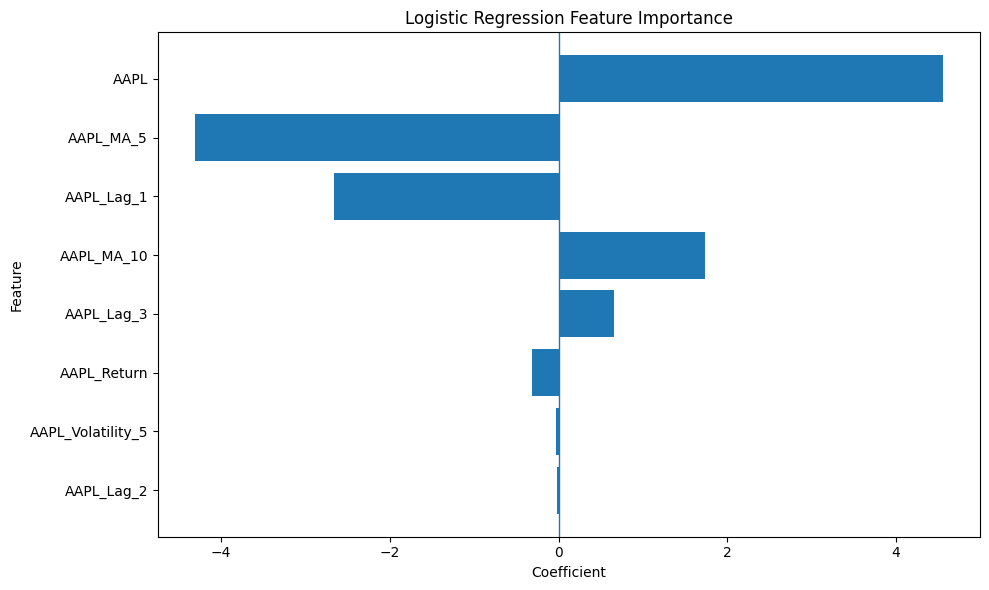

In [99]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

ROC-AUC: 0.5032679738562091


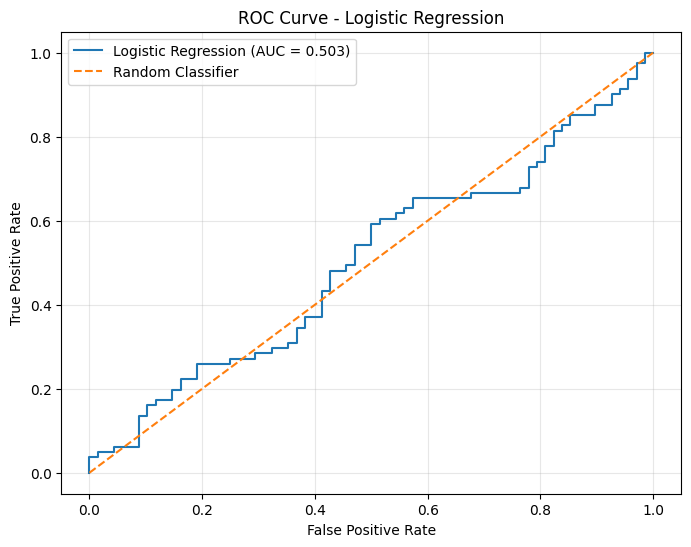

In [100]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
y_prob_lr = grid_lr_balanced.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Calculate AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC:", auc_lr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [101]:
df["AAPL_Target_5D"] = (
    df["AAPL"].shift(-5) > df["AAPL"]
).astype(int)

# Remove the last 5 rows because they don't have a future 5-day price
df_5d = df.iloc[:-5].copy().reset_index(drop=True)

print("Shape:", df_5d.shape)

print("\nTarget distribution:")
print(df_5d["AAPL_Target_5D"].value_counts())

print("\nTarget distribution (%):")
print(df_5d["AAPL_Target_5D"].value_counts(normalize=True))

Shape: (736, 47)

Target distribution:
AAPL_Target_5D
1    405
0    331
Name: count, dtype: int64

Target distribution (%):
AAPL_Target_5D
1    0.550272
0    0.449728
Name: proportion, dtype: float64


In [102]:
X_5d = df_5d[aapl_features]
y_5d = df_5d["AAPL_Target_5D"]

train_size_5d = int(len(df_5d) * 0.8)

X_5d_train = X_5d.iloc[:train_size_5d]
X_5d_test = X_5d.iloc[train_size_5d:]

y_5d_train = y_5d.iloc[:train_size_5d]
y_5d_test = y_5d.iloc[train_size_5d:]

print("X_train:", X_5d_train.shape)
print("X_test:", X_5d_test.shape)
print("y_train:", y_5d_train.shape)
print("y_test:", y_5d_test.shape)

print("\nTrain dates:")
print(
    df_5d["Date"].iloc[0],
    "to",
    df_5d["Date"].iloc[train_size_5d - 1]
)

print("\nTest dates:")
print(
    df_5d["Date"].iloc[train_size_5d],
    "to",
    df_5d["Date"].iloc[-1]
)

X_train: (588, 8)
X_test: (148, 8)
y_train: (588,)
y_test: (148,)

Train dates:
2023-09-15 00:00:00 to 2026-01-20 00:00:00

Test dates:
2026-01-21 00:00:00 to 2026-08-21 00:00:00


In [103]:
tscv_5d = TimeSeriesSplit(n_splits=5)

logistic_5d_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

param_grid_lr_5d = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lr_5d = GridSearchCV(
    estimator=logistic_5d_pipeline,
    param_grid=param_grid_lr_5d,
    cv=tscv_5d,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_lr_5d.fit(X_5d_train, y_5d_train)

print("Best Parameters:", grid_lr_5d.best_params_)
print("Best CV Balanced Accuracy:", grid_lr_5d.best_score_)

Best Parameters: {'model__C': 0.001}
Best CV Balanced Accuracy: 0.5763476430976431


In [104]:
y_pred_lr_5d = grid_lr_5d.predict(X_5d_test)

print("Test Accuracy:",
      accuracy_score(y_5d_test, y_pred_lr_5d))

print("\nClassification Report:")
print(classification_report(y_5d_test, y_pred_lr_5d))

print("Confusion Matrix:")
print(confusion_matrix(y_5d_test, y_pred_lr_5d))

print("\nBalanced Accuracy:",
      balanced_accuracy_score(y_5d_test, y_pred_lr_5d))

print("Macro F1:",
      f1_score(y_5d_test, y_pred_lr_5d, average="macro"))

Test Accuracy: 0.5675675675675675

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.92      0.63        59
           1       0.86      0.34      0.48        89

    accuracy                           0.57       148
   macro avg       0.67      0.63      0.56       148
weighted avg       0.71      0.57      0.54       148

Confusion Matrix:
[[54  5]
 [59 30]]

Balanced Accuracy: 0.6261664444867644
Macro F1: 0.5558889722430608


In [105]:
rf_5d_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_rf_5d = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10]
}

grid_rf_5d = GridSearchCV(
    estimator=rf_5d_pipeline,
    param_grid=param_grid_rf_5d,
    cv=tscv_5d,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_rf_5d.fit(X_5d_train, y_5d_train)

print("Best Parameters:", grid_rf_5d.best_params_)
print("Best CV Balanced Accuracy:", grid_rf_5d.best_score_)


Best Parameters: {'model__max_depth': 5, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best CV Balanced Accuracy: 0.5311256949338345


In [106]:
y_pred_rf_5d = grid_rf_5d.predict(X_5d_test)

print("Test Accuracy:",
      accuracy_score(y_5d_test, y_pred_rf_5d))

print("\nClassification Report:")
print(classification_report(y_5d_test, y_pred_rf_5d))

print("Confusion Matrix:")
print(confusion_matrix(y_5d_test, y_pred_rf_5d))

print("\nBalanced Accuracy:",
      balanced_accuracy_score(y_5d_test, y_pred_rf_5d))

print("Macro F1:",
      f1_score(y_5d_test, y_pred_rf_5d, average="macro"))

Test Accuracy: 0.5405405405405406

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.69      0.55        59
           1       0.68      0.44      0.53        89

    accuracy                           0.54       148
   macro avg       0.57      0.57      0.54       148
weighted avg       0.59      0.54      0.54       148

Confusion Matrix:
[[41 18]
 [50 39]]

Balanced Accuracy: 0.5665587507141497
Macro F1: 0.5404566210045663


In [107]:
xgb_5d_pipeline = Pipeline([
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

param_grid_xgb_5d = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

grid_xgb_5d = GridSearchCV(
    estimator=xgb_5d_pipeline,
    param_grid=param_grid_xgb_5d,
    cv=tscv_5d,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_xgb_5d.fit(X_5d_train, y_5d_train)

print("Best Parameters:", grid_xgb_5d.best_params_)
print("Best CV Balanced Accuracy:", grid_xgb_5d.best_score_)

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV Balanced Accuracy: 0.5573132487667372


In [108]:
y_pred_xgb_5d = grid_xgb_5d.predict(X_5d_test)

print("Test Accuracy:",
      accuracy_score(y_5d_test, y_pred_xgb_5d))

print("\nClassification Report:")
print(classification_report(y_5d_test, y_pred_xgb_5d))

print("Confusion Matrix:")
print(confusion_matrix(y_5d_test, y_pred_xgb_5d))

print("\nBalanced Accuracy:",
      balanced_accuracy_score(y_5d_test, y_pred_xgb_5d))

print("Macro F1:",
      f1_score(y_5d_test, y_pred_xgb_5d, average="macro"))

Test Accuracy: 0.5472972972972973

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.46      0.45        59
           1       0.63      0.61      0.62        89

    accuracy                           0.55       148
   macro avg       0.53      0.53      0.53       148
weighted avg       0.55      0.55      0.55       148

Confusion Matrix:
[[27 32]
 [35 54]]

Balanced Accuracy: 0.5321843458388879
Macro F1: 0.5317119244391971


In [109]:
# Final evaluation for 5-Day Logistic Regression

from sklearn.metrics import roc_curve, roc_auc_score

# Predictions
y_pred_final = grid_lr_5d.predict(X_5d_test)

# Probabilities for ROC-AUC
y_prob_final = grid_lr_5d.predict_proba(X_5d_test)[:, 1]

# Metrics
final_accuracy = accuracy_score(y_5d_test, y_pred_final)
final_balanced_accuracy = balanced_accuracy_score(y_5d_test, y_pred_final)
final_macro_f1 = f1_score(y_5d_test, y_pred_final, average="macro")
final_auc = roc_auc_score(y_5d_test, y_prob_final)

print("FINAL 5-DAY LOGISTIC REGRESSION")
print("=" * 40)

print(f"Accuracy:           {final_accuracy:.4f}")
print(f"Balanced Accuracy:  {final_balanced_accuracy:.4f}")
print(f"Macro F1:           {final_macro_f1:.4f}")
print(f"ROC-AUC:            {final_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_5d_test, y_pred_final))

print("Confusion Matrix:")
print(confusion_matrix(y_5d_test, y_pred_final))

FINAL 5-DAY LOGISTIC REGRESSION
Accuracy:           0.5676
Balanced Accuracy:  0.6262
Macro F1:           0.5559
ROC-AUC:            0.6220

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.92      0.63        59
           1       0.86      0.34      0.48        89

    accuracy                           0.57       148
   macro avg       0.67      0.63      0.56       148
weighted avg       0.71      0.57      0.54       148

Confusion Matrix:
[[54  5]
 [59 30]]


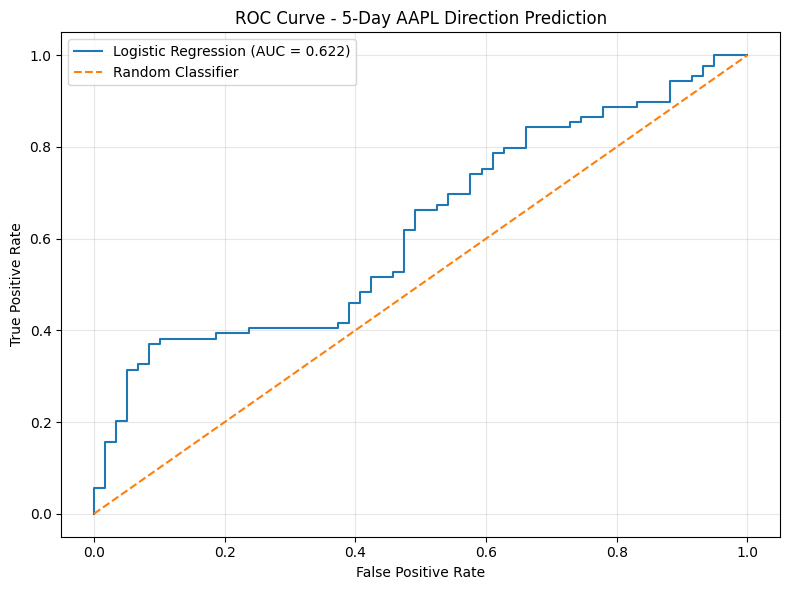

In [110]:
# Final ROC Curve - 5-Day Logistic Regression

fpr_final, tpr_final, thresholds_final = roc_curve(
    y_5d_test,
    y_prob_final
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_final,
    tpr_final,
    label=f"Logistic Regression (AUC = {final_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 5-Day AAPL Direction Prediction")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [111]:
import joblib

# Save the best 5-day Logistic Regression model
joblib.dump(grid_lr_5d, "aapl_5day_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [112]:
def predict_aapl_5days(features):
    prediction = grid_lr_5d.predict(features)[0]
    probabilities = grid_lr_5d.predict_proba(features)[0]

    if prediction == 1:
        direction = "UP 📈"
    else:
        direction = "DOWN 📉"

    return {
        "Prediction": direction,
        "DOWN Probability": probabilities[0],
        "UP Probability": probabilities[1]
    }

In [113]:
# Get the latest available AAPL features
latest_features = df[aapl_features].iloc[[-1]]

# Make prediction
result = predict_aapl_5days(latest_features)

print("AAPL 5-Day Prediction")
print("----------------------")
print("Prediction:", result["Prediction"])
print(f"DOWN Probability: {result['DOWN Probability']:.2%}")
print(f"UP Probability: {result['UP Probability']:.2%}")

AAPL 5-Day Prediction
----------------------
Prediction: DOWN 📉
DOWN Probability: 54.66%
UP Probability: 45.34%


In [114]:
def prepare_aapl_features(prices):
    data = pd.DataFrame({"AAPL": prices})

    data["AAPL_Return"] = data["AAPL"].pct_change()
    data["AAPL_MA_5"] = data["AAPL"].rolling(window=5).mean()
    data["AAPL_MA_10"] = data["AAPL"].rolling(window=10).mean()

    data["AAPL_Lag_1"] = data["AAPL"].shift(1)
    data["AAPL_Lag_2"] = data["AAPL"].shift(2)
    data["AAPL_Lag_3"] = data["AAPL"].shift(3)

    data["AAPL_Volatility_5"] = (
        data["AAPL_Return"].rolling(window=5).std()
    )

    return data[aapl_features].dropna()

In [115]:
# Prepare features from AAPL prices
test_features = prepare_aapl_features(df["AAPL"])

print("Features prepared successfully!")
print("Shape:", test_features.shape)
print("\nLatest features:")
print(test_features.tail(1))

Features prepared successfully!
Shape: (732, 8)

Latest features:
           AAPL  AAPL_Return  AAPL_MA_5  AAPL_MA_10  AAPL_Lag_1  AAPL_Lag_2  \
740  319.700012     0.016276    313.594  312.106998  314.579987  313.450012   

     AAPL_Lag_3  AAPL_Volatility_5  
740  309.899994           0.007106  


In [116]:
def predict_from_prices(prices):
    features = prepare_aapl_features(prices)

    latest_features = features.iloc[[-1]]

    prediction = grid_lr_5d.predict(latest_features)[0]
    probabilities = grid_lr_5d.predict_proba(latest_features)[0]

    if prediction == 1:
        direction = "UP 📈"
    else:
        direction = "DOWN 📉"

    return {
        "Prediction": direction,
        "DOWN Probability": probabilities[0],
        "UP Probability": probabilities[1]
    }

In [117]:
result = predict_from_prices(df["AAPL"])

print("AAPL 5-Day Prediction")
print("----------------------")
print("Prediction:", result["Prediction"])
print(f"DOWN Probability: {result['DOWN Probability']:.2%}")
print(f"UP Probability: {result['UP Probability']:.2%}")

AAPL 5-Day Prediction
----------------------
Prediction: DOWN 📉
DOWN Probability: 54.66%
UP Probability: 45.34%


In [118]:
import yfinance as yf

aapl_live = yf.Ticker("AAPL")

live_data = aapl_live.history(period="1mo", interval="1d")

print(live_data.tail())

                                 Open        High         Low       Close  \
Date                                                                        
2026-09-16 00:00:00-04:00  332.529999  335.480011  330.700012  332.410004   
2026-09-17 00:00:00-04:00  334.769989  338.339996  330.179993  337.000000   
2026-09-18 00:00:00-04:00  337.910004  338.489990  332.529999  336.130005   
2026-09-21 00:00:00-04:00  335.279999  339.640015  333.049988  338.980011   
2026-09-22 00:00:00-04:00  340.329987  345.339996  338.750000  342.255005   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-09-16 00:00:00-04:00  35981000        0.0           0.0  
2026-09-17 00:00:00-04:00  36700200        0.0           0.0  
2026-09-18 00:00:00-04:00  86588200        0.0           0.0  
2026-09-21 00:00:00-04:00  34955500        0.0           0.0  
2026-09-22 00:00:00-04:00  18001545        0.0           0.0  


In [119]:
# Prepare live AAPL closing prices
live_prices = live_data["Close"].rename("AAPL")

print("Latest AAPL price:", live_prices.iloc[-1])
print("\nLast 5 prices:")
print(live_prices.tail())

Latest AAPL price: 342.2550048828125

Last 5 prices:
Date
2026-09-16 00:00:00-04:00    332.410004
2026-09-17 00:00:00-04:00    337.000000
2026-09-18 00:00:00-04:00    336.130005
2026-09-21 00:00:00-04:00    338.980011
2026-09-22 00:00:00-04:00    342.255005
Name: AAPL, dtype: float64


In [120]:
# Prepare features from live AAPL data
live_features = prepare_aapl_features(live_prices)

# Get the latest available features
latest_live_features = live_features.iloc[[-1]]

print("Latest live features:")
print(latest_live_features)

Latest live features:
                                 AAPL  AAPL_Return   AAPL_MA_5  AAPL_MA_10  \
Date                                                                         
2026-09-22 00:00:00-04:00  342.255005     0.009661  337.355005    332.5375   

                           AAPL_Lag_1  AAPL_Lag_2  AAPL_Lag_3  \
Date                                                            
2026-09-22 00:00:00-04:00  338.980011  336.130005       337.0   

                           AAPL_Volatility_5  
Date                                          
2026-09-22 00:00:00-04:00           0.006334  


In [121]:
live_prediction = grid_lr_5d.predict(latest_live_features)[0]
live_probabilities = grid_lr_5d.predict_proba(latest_live_features)[0]

if live_prediction == 1:
    live_direction = "UP 📈"
else:
    live_direction = "DOWN 📉"

print("AAPL Live 5-Day Prediction")
print("---------------------------")
print("Latest Price:", f"${latest_live_features['AAPL'].iloc[0]:.2f}")
print("Prediction:", live_direction)
print(f"DOWN Probability: {live_probabilities[0]:.2%}")
print(f"UP Probability: {live_probabilities[1]:.2%}")

AAPL Live 5-Day Prediction
---------------------------
Latest Price: $342.26
Prediction: DOWN 📉
DOWN Probability: 56.62%
UP Probability: 43.38%
